In [532]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [533]:
df = pd.read_csv("../data/sales.csv", sep=",")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [534]:
df.shape

(200, 5)

In [535]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [536]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [537]:
df.rename(columns={"Unnamed: 0": "Id"}, inplace=True)

In [538]:
df.head()

,Id,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [539]:
df.duplicated().sum()

np.int64(0)

In [540]:
### VISUALIZATION

In [541]:
vis_cols = ['TV', 'Radio', 'Newspaper']

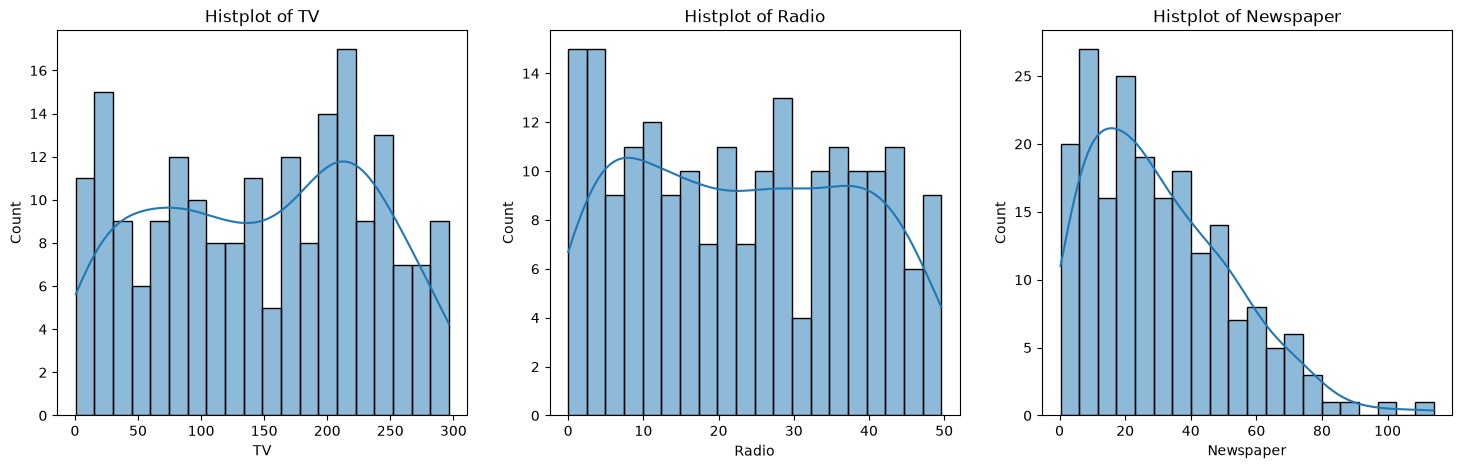

In [542]:
fig, axes = plt.subplots(1,3, figsize=(18,5))
axes = axes.flatten()

for i, col in enumerate(vis_cols):
    sns.histplot(x=col, data=df, bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Histplot of {col}")
plt.show()

In [543]:
df["Sales"].unique()

array([22.1, 10.4,  9.3, 18.5, 12.9,  7.2, 11.8, 13.2,  4.8, 10.6,  8.6,
       17.4,  9.2,  9.7, 19. , 22.4, 12.5, 24.4, 11.3, 14.6, 18. ,  5.6,
       15.5, 12. , 15. , 15.9, 18.9, 10.5, 21.4, 11.9,  9.6,  9.5, 12.8,
       25.4, 14.7, 10.1, 21.5, 16.6, 17.1, 20.7,  8.5, 14.9, 23.2, 14.8,
       11.4, 10.7, 22.6, 21.2, 20.2, 23.7,  5.5, 23.8, 18.4,  8.1, 24.2,
       15.7, 14. , 13.4, 22.3, 18.3, 12.4,  8.8, 11. , 17. ,  8.7,  6.9,
       14.2,  5.3, 12.3, 13.6, 21.7, 15.2, 16. , 16.7, 11.2,  7.3, 19.4,
       22.2, 11.5, 16.9, 11.7, 17.2, 19.2, 19.8, 21.8, 14.1, 12.6, 12.2,
        9.4,  6.6,  7. , 11.6, 19.7, 24.7,  1.6, 12.7,  5.7, 19.6, 10.8,
       20.8, 10.9, 20.1, 10.3, 16.1, 15.6,  3.2, 15.3, 14.4, 13.3,  8. ,
        8.4, 14.5,  7.6, 27. , 26.2, 17.6, 17.3,  6.7,  9.9,  5.9, 25.5])

In [544]:
def sales_transform(sales_value):
    if 0 <= sales_value < 10:
        return "Low Sale"
    elif 10 <= sales_value < 15:
        return "Medium Sale"
    elif sales_value >= 15:
        return "High Sale"
    else:
        return "Invalid Sale"
    

In [545]:
df["Sales_Status"] = df["Sales"].apply(sales_transform)

In [546]:
df.head()

,Id,TV,Radio,Newspaper,Sales,Sales_Status
0,1,230.1,37.8,69.2,22.1,High Sale
1,2,44.5,39.3,45.1,10.4,Medium Sale
2,3,17.2,45.9,69.3,9.3,Low Sale
3,4,151.5,41.3,58.5,18.5,High Sale
4,5,180.8,10.8,58.4,12.9,Medium Sale


In [547]:
df["Sales_Status"].unique()

<ArrowStringArray>
['High Sale', 'Medium Sale', 'Low Sale']
Length: 3, dtype: str

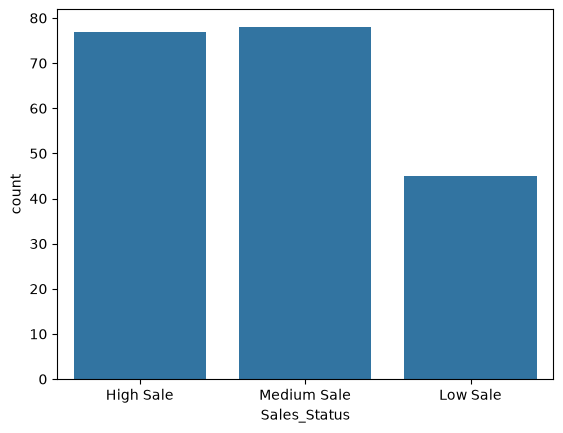

In [548]:
sns.countplot(x="Sales_Status", data=df)
plt.show()


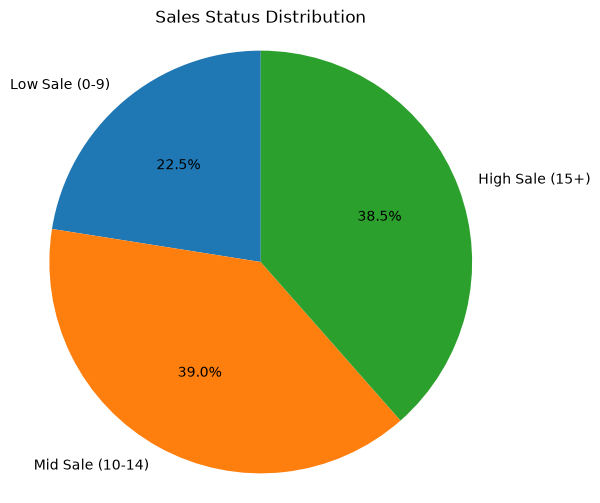

In [549]:
order = ["Low Sale", "Medium Sale", "High Sale"]
counts = df["Sales_Status"].value_counts().reindex(order)

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=["Low Sale (0-9)", "Mid Sale (10-14)", "High Sale (15+)"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Status Distribution")
plt.axis("equal")
plt.show()

In [550]:
df["Total_Spend"] = df["TV"] + df["Radio"] + df["Newspaper"]

In [551]:
df.head()

,Id,TV,Radio,Newspaper,Sales,Sales_Status,Total_Spend
0,1,230.1,37.8,69.2,22.1,High Sale,337.1
1,2,44.5,39.3,45.1,10.4,Medium Sale,128.9
2,3,17.2,45.9,69.3,9.3,Low Sale,132.4
3,4,151.5,41.3,58.5,18.5,High Sale,251.3
4,5,180.8,10.8,58.4,12.9,Medium Sale,250.0


In [552]:
df["TV_Radio"] = df["TV"] * df["Radio"]
df["TV_Newspaper"] = df["TV"] * df["Newspaper"]
df["Radio_Newspaper"] = df["Radio"] * df["Newspaper"]

df["Dominant_Channel"] = df[["TV", "Radio", "Newspaper"]].idxmax(axis=1)

In [553]:
df.drop(columns=["Id"], inplace=True)

In [554]:
df.head()

,TV,Radio,Newspaper,Sales,Sales_Status,Total_Spend,TV_Radio,TV_Newspaper,Radio_Newspaper,Dominant_Channel
0,230.1,37.8,69.2,22.1,High Sale,337.1,8697.78,15922.92,2615.76,TV
1,44.5,39.3,45.1,10.4,Medium Sale,128.9,1748.85,2006.95,1772.43,Newspaper
2,17.2,45.9,69.3,9.3,Low Sale,132.4,789.48,1191.96,3180.87,Newspaper
3,151.5,41.3,58.5,18.5,High Sale,251.3,6256.95,8862.75,2416.05,TV
4,180.8,10.8,58.4,12.9,Medium Sale,250.0,1952.64,10558.72,630.72,TV


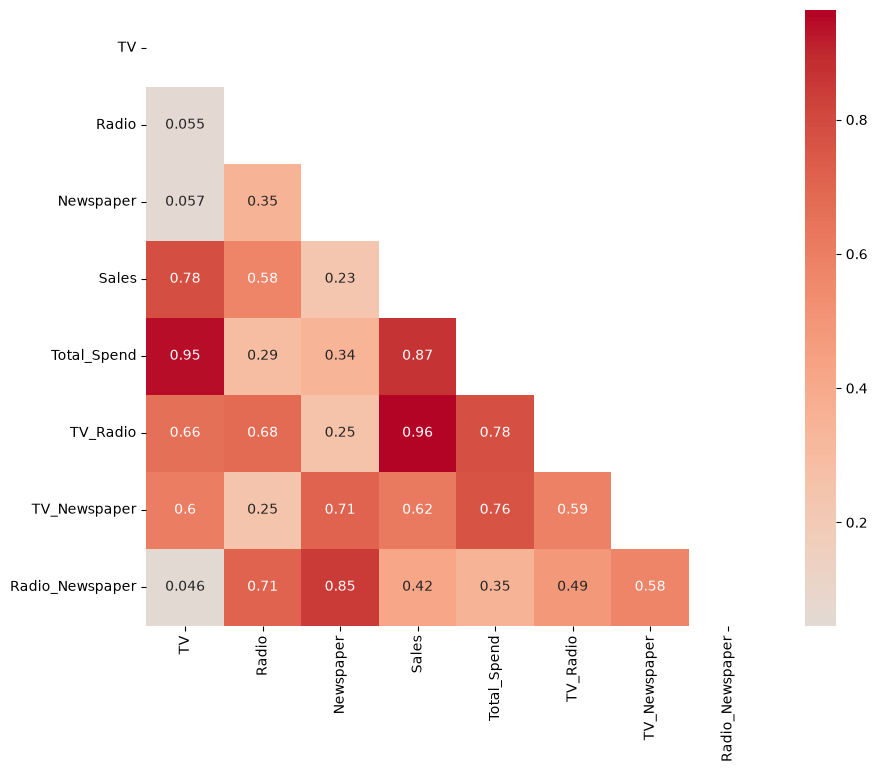

In [555]:
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(numeric_only=True), dtype=bool))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", mask=mask, center=0)
plt.show()

In [556]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TV                200 non-null    float64
 1   Radio             200 non-null    float64
 2   Newspaper         200 non-null    float64
 3   Sales             200 non-null    float64
 4   Sales_Status      200 non-null    str    
 5   Total_Spend       200 non-null    float64
 6   TV_Radio          200 non-null    float64
 7   TV_Newspaper      200 non-null    float64
 8   Radio_Newspaper   200 non-null    float64
 9   Dominant_Channel  200 non-null    str    
dtypes: float64(8), str(2)
memory usage: 18.2 KB


In [557]:
num_cols = df.select_dtypes(include=["float64"]).columns

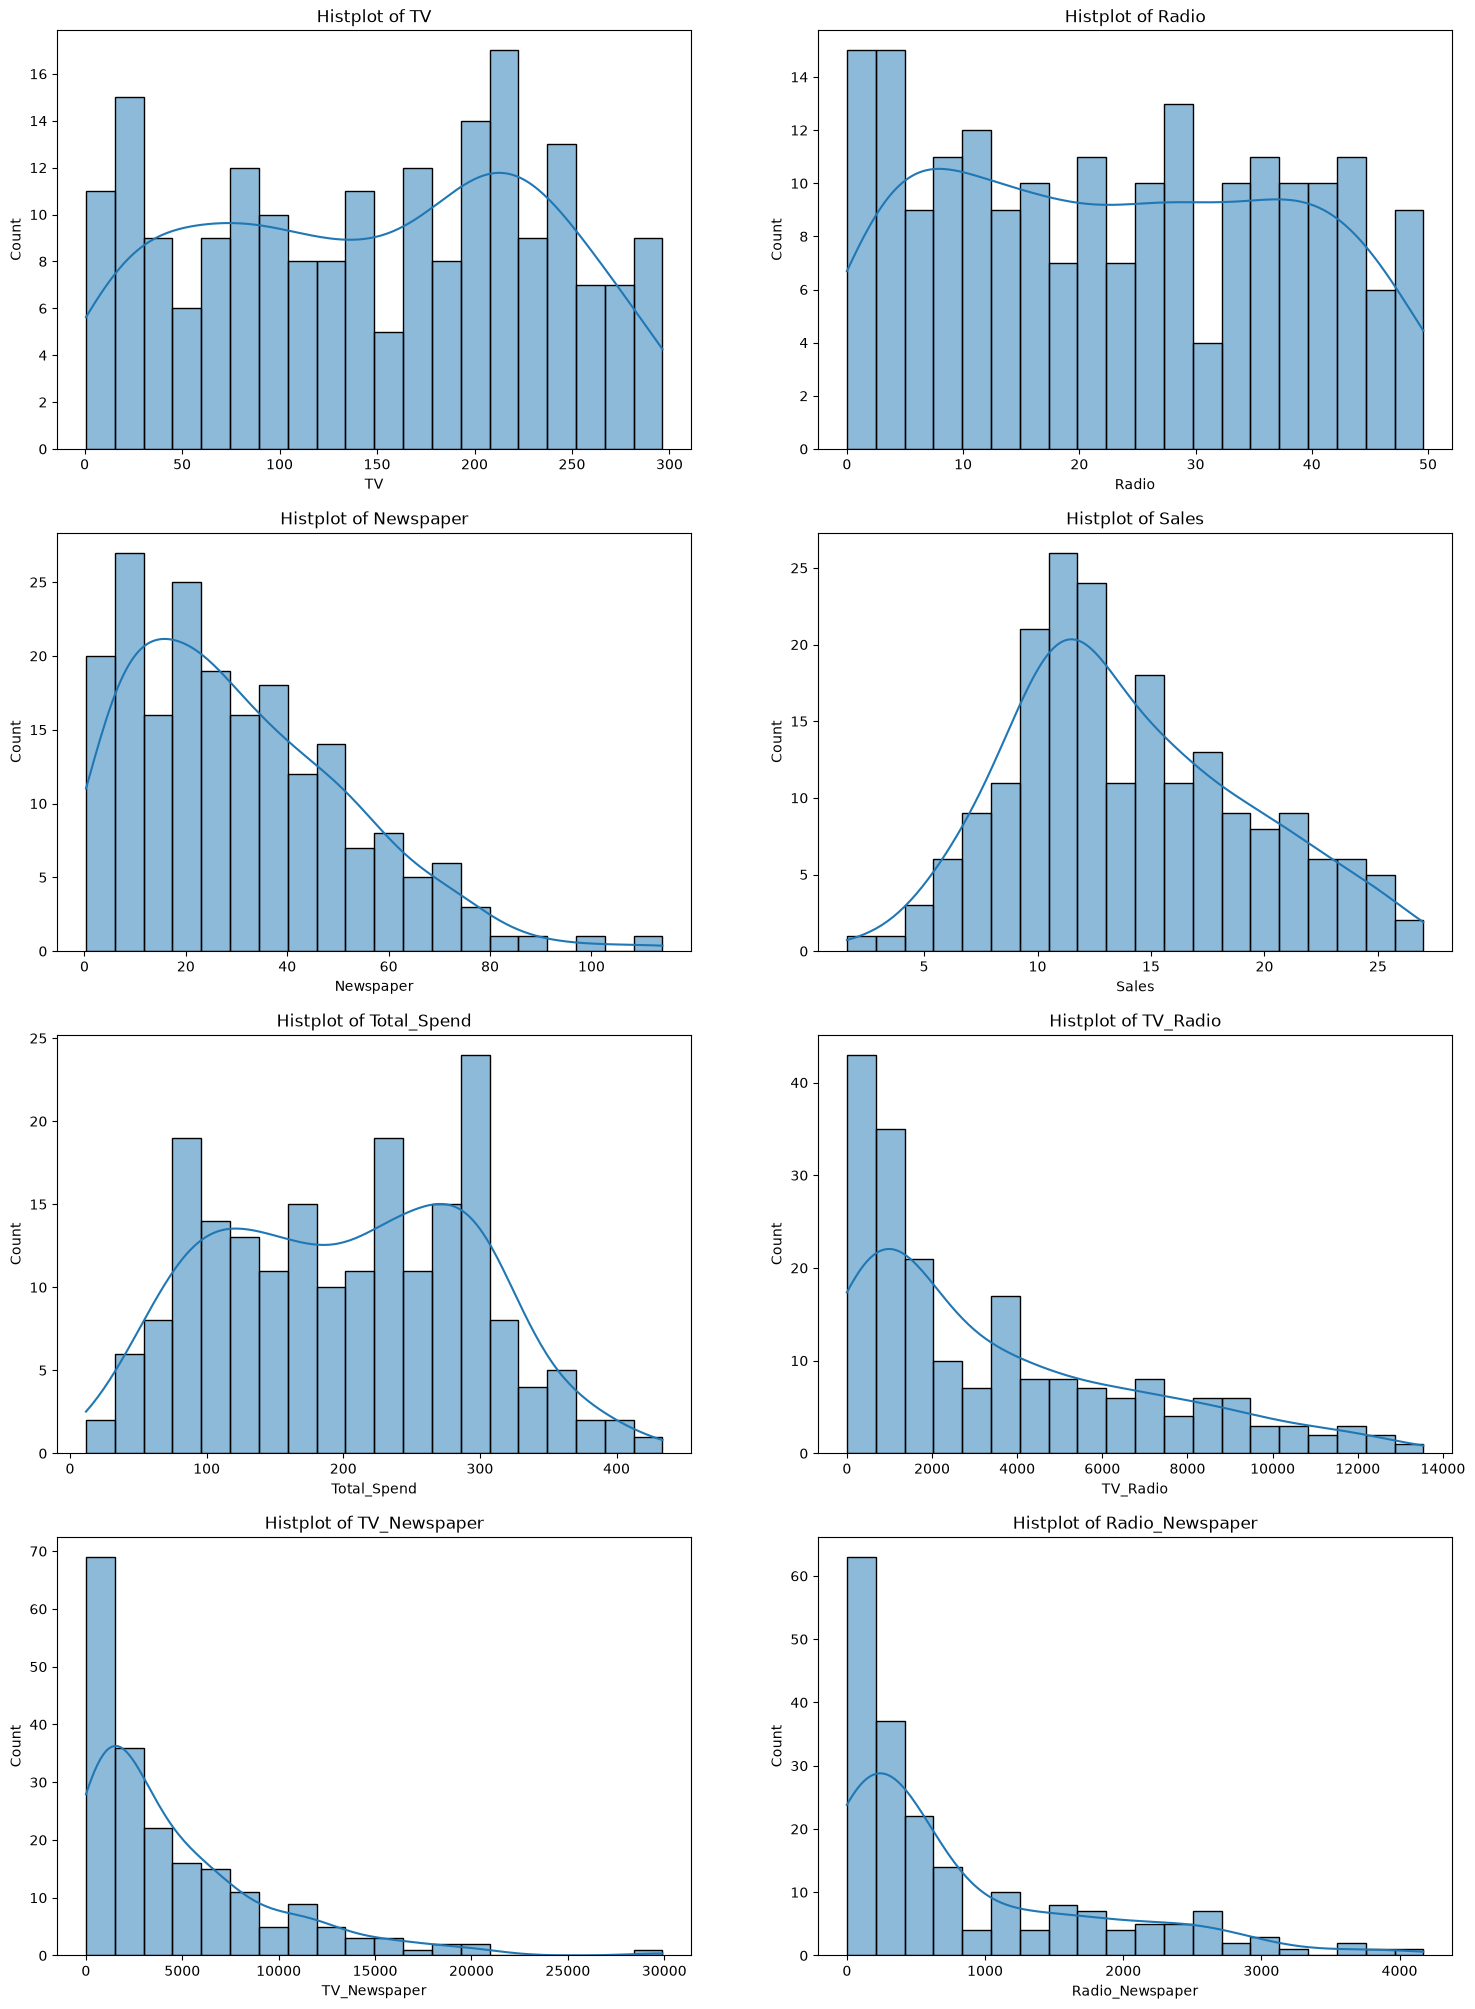

In [558]:
fig, axes = plt.subplots(4,2, figsize=(18,25))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=col, data=df, bins=20, kde=True, ax=axes[i])
    axes[i].set_title(f"Histplot of {col}")
plt.show()

In [559]:
for i in num_cols:
    print(f"Before transformation {i}: {df[i].skew()}")
    print(f"After transformation {i}: {(np.log1p(df[i])).skew()}\n")

Before transformation TV: -0.06985336213274573
After transformation TV: -1.479682962981254

Before transformation Radio: 0.09417463149664404
After transformation Radio: -1.0221455880884112

Before transformation Newspaper: 0.8947204074986175
After transformation Newspaper: -0.7998749355228586

Before transformation Sales: 0.4075714250767127
After transformation Sales: -0.7017696231413868

Before transformation Total_Spend: 0.04948799338306634
After transformation Total_Spend: -1.1448228544572057

Before transformation TV_Radio: 1.0134048429641285
After transformation TV_Radio: -1.3671859198384961

Before transformation TV_Newspaper: 1.7868051163270753
After transformation TV_Newspaper: -1.1721461334502858

Before transformation Radio_Newspaper: 1.3941069363585312
After transformation Radio_Newspaper: -0.7186641179494341



In [560]:
df.skew(numeric_only=True)

TV                -0.069853
Radio              0.094175
Newspaper          0.894720
Sales              0.407571
Total_Spend        0.049488
TV_Radio           1.013405
TV_Newspaper       1.786805
Radio_Newspaper    1.394107
dtype: float64

1) Log transformation
2) Power transformation
3) Quantitle transformation
4) Standard Scaler
5) MinMax Scaler

#### Log transformation to perform training

In [561]:
df_log = df.copy()

In [562]:
for col in num_cols:
    if df_log[col].skew() > 1:
        df_log[col] = np.log1p(df_log[col])

In [563]:
df_log.head()

,TV,Radio,Newspaper,Sales,Sales_Status,Total_Spend,TV_Radio,TV_Newspaper,Radio_Newspaper,Dominant_Channel
0,230.1,37.8,69.2,22.1,High Sale,337.1,9.070938,9.675578,7.869692,TV
1,44.5,39.3,45.1,10.4,Medium Sale,128.9,7.467285,7.604870,7.480671,Newspaper
2,17.2,45.9,69.3,9.3,Low Sale,132.4,6.672640,7.084193,8.065224,Newspaper
3,151.5,41.3,58.5,18.5,High Sale,251.3,8.741608,9.089725,7.790303,TV
4,180.8,10.8,58.4,12.9,Medium Sale,250.0,7.577450,9.264802,6.448446,TV


In [564]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


ohe_cols = ['Dominant_Channel']

processor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols)
    ],
    remainder='passthrough'
)

In [565]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


models = {
    'LR' : LinearRegression(),
    'XG' : XGBRegressor(),
    "DT" : DecisionTreeRegressor(),
    "RT" : RandomForestRegressor()
}

In [566]:
X = df_log.drop(["Sales", "Sales_Status", "Total_Spend"], axis=1)
y= df_log["Sales"]

In [567]:
X.head()

,TV,Radio,Newspaper,TV_Radio,TV_Newspaper,Radio_Newspaper,Dominant_Channel
0,230.1,37.8,69.2,9.070938,9.675578,7.869692,TV
1,44.5,39.3,45.1,7.467285,7.604870,7.480671,Newspaper
2,17.2,45.9,69.3,6.672640,7.084193,8.065224,Newspaper
3,151.5,41.3,58.5,8.741608,9.089725,7.790303,TV
4,180.8,10.8,58.4,7.577450,9.264802,6.448446,TV


In [568]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state=42
)

In [569]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((140, 7), (140,), (60, 7), (60,))

In [570]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

log_results = []
trained_models_log ={}

for name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("processor", processor ),
            ("model", model)
        ]
    )
    cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring='r2',
    )
    
    
    pipeline.fit(X_train, y_train)
    
    trained_models_log[name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    cv_mean = cv.mean()
    cv_std = cv.std()
    
    
    log_results.append({
        'name' : name,
        "r2" : r2,
        "rmse" : rmse,
        "mse": mse,
        "cv_mean" : cv_mean,
        "cv_std" : cv_std
    })
    
    

In [571]:
print(log_results)

[{'name': 'LR', 'r2': 0.9110684424033594, 'rmse': 1.5582815370303102, 'mse': 2.428241348649546, 'cv_mean': np.float64(0.9211278921291726), 'cv_std': np.float64(0.015512755910369505)}, {'name': 'XG', 'r2': 0.9790765273398742, 'rmse': 0.7558486792724753, 'mse': 0.5713072259579454, 'cv_mean': np.float64(0.9782055271059411), 'cv_std': np.float64(0.016151431070802878)}, {'name': 'DT', 'r2': 0.9658787756523395, 'rmse': 0.965228815704684, 'mse': 0.9316666666666668, 'cv_mean': np.float64(0.9663922611970476), 'cv_std': np.float64(0.009638545553251821)}, {'name': 'RT', 'r2': 0.9903766903816297, 'rmse': 0.512601892310202, 'mse': 0.2627607, 'cv_mean': np.float64(0.9779227710997999), 'cv_std': np.float64(0.016685099791646604)}]


In [572]:
log_results_df = pd.DataFrame(log_results)

log_results_df = log_results_df.sort_values(
    by="r2",
    ascending=False
).reset_index(drop=True)

print(log_results_df)

  name        r2      rmse       mse   cv_mean    cv_std
0   RT  0.990377  0.512602  0.262761  0.977923  0.016685
1   XG  0.979077  0.755849  0.571307  0.978206  0.016151
2   DT  0.965879  0.965229  0.931667  0.966392  0.009639
3   LR  0.911068  1.558282  2.428241  0.921128  0.015513


In [573]:
import joblib

joblib.dump(trained_models_log['RT'], open("../model/best_model_log.pkl", "wb"))

In [574]:
bm = joblib.load("../model/best_model_log.pkl")
print(type(bm))

<class 'sklearn.pipeline.Pipeline'>


### PowerTransformer


In [575]:
df_power = df.copy()

In [576]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')


In [577]:
transformers = {}

for col in num_cols:
    print(col, df_power[col].skew())   # Check skewness

    if df_power[col].skew() > 1:
        print(f"Transforming {col}")
        pt = PowerTransformer(method="yeo-johnson")
        df_power[col] = pt.fit_transform(df_power[[col]]).ravel()
        transformers[col] = pt

print(transformers.keys())
joblib.dump(transformers, open("../model/power_transformers.pkl", "wb"))

TV -0.06985336213274573
Radio 0.09417463149664404
Newspaper 0.8947204074986175
Sales 0.4075714250767127
Total_Spend 0.04948799338306634
TV_Radio 1.0134048429641285
Transforming TV_Radio
TV_Newspaper 1.7868051163270753
Transforming TV_Newspaper
Radio_Newspaper 1.3941069363585312
Transforming Radio_Newspaper
dict_keys(['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper'])


In [578]:
power_transformers = joblib.load("../model/power_transformers.pkl")
print(power_transformers.keys())

dict_keys(['TV_Radio', 'TV_Newspaper', 'Radio_Newspaper'])


In [579]:
df_power.head()

,TV,Radio,Newspaper,Sales,Sales_Status,Total_Spend,TV_Radio,TV_Newspaper,Radio_Newspaper,Dominant_Channel
0,230.1,37.8,69.2,22.1,High Sale,337.1,1.328881,1.723421,1.487903,TV
1,44.5,39.3,45.1,10.4,Medium Sale,128.9,-0.200907,-0.285206,1.123453,Newspaper
2,17.2,45.9,69.3,9.3,Low Sale,132.4,-0.731908,-0.648552,1.681129,Newspaper
3,151.5,41.3,58.5,18.5,High Sale,251.3,0.953953,1.047836,1.411404,TV
4,180.8,10.8,58.4,12.9,Medium Sale,250.0,-0.117112,1.239616,0.273381,TV


In [580]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


ohe_cols = ['Dominant_Channel']

processor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols)
    ],
    remainder='passthrough'
)

In [581]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


models = {
    'LR' : LinearRegression(),
    'XG' : XGBRegressor(),
    "DT" : DecisionTreeRegressor(),
    "RT" : RandomForestRegressor()
}

In [582]:
X = df_power.drop(["Sales", "Sales_Status", "Total_Spend"], axis=1)
y= df_power["Sales"]

In [583]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state=42
)

In [584]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

pt_results = []
trained_models_pt ={}

for name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("processor", processor ),
            ("model", model)
        ]
    )
    cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring='r2',
    )
    
    
    pipeline.fit(X_train, y_train)
    
    trained_models_pt[name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    cv_mean = cv.mean()
    cv_std = cv.std()
    
    
    pt_results.append({
        'name' : name,
        "r2" : r2,
        "rmse" : rmse,
        "mse": mse,
        "cv_mean" : cv_mean,
        "cv_std" : cv_std
    })
    
    

In [585]:
pt_results_df = pd.DataFrame(pt_results)

pt_results_df = pt_results_df.sort_values(
    by="r2",
    ascending=False
).reset_index(drop=True)

print(pt_results_df)

  name        r2      rmse       mse   cv_mean    cv_std
0   RT  0.988558  0.558949  0.312423  0.977972  0.016654
1   XG  0.979077  0.755849  0.571307  0.978206  0.016151
2   DT  0.972349  0.868907  0.755000  0.969454  0.007182
3   LR  0.961028  1.031558  1.064112  0.963009  0.006698


In [586]:
import joblib

joblib.dump(trained_models_pt['RT'], open("../model/best_model_pt.pkl", "wb"))

In [587]:
bm_pt = joblib.load("../model/best_model_pt.pkl")
print(type(bm_pt))

<class 'sklearn.pipeline.Pipeline'>


### StandardScaler

In [588]:
df_ss = df.copy()
df_ss.head()

,TV,Radio,Newspaper,Sales,Sales_Status,Total_Spend,TV_Radio,TV_Newspaper,Radio_Newspaper,Dominant_Channel
0,230.1,37.8,69.2,22.1,High Sale,337.1,8697.78,15922.92,2615.76,TV
1,44.5,39.3,45.1,10.4,Medium Sale,128.9,1748.85,2006.95,1772.43,Newspaper
2,17.2,45.9,69.3,9.3,Low Sale,132.4,789.48,1191.96,3180.87,Newspaper
3,151.5,41.3,58.5,18.5,High Sale,251.3,6256.95,8862.75,2416.05,TV
4,180.8,10.8,58.4,12.9,Medium Sale,250.0,1952.64,10558.72,630.72,TV


In [589]:
num_cols = ['TV', 'Radio', 'Newspaper', 'TV_Radio',
       'TV_Newspaper', 'Radio_Newspaper']

ohe_cols

['Dominant_Channel']

In [590]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


ohe_cols = ['Dominant_Channel']

processor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

In [591]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


models = {
    'LR' : LinearRegression(),
    'XG' : XGBRegressor(),
    "DT" : DecisionTreeRegressor(),
    "RT" : RandomForestRegressor()
}

In [592]:
X = df_ss.drop(["Sales", "Sales_Status", "Total_Spend"], axis=1)
y= df_ss["Sales"]

In [593]:
y.head()

0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64

In [594]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state=42
)

In [595]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ss_results = []
trained_models_ss ={}

for name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("processor", processor ),
            ("model", model)
        ]
    )
    cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring='r2',
    )
    
    
    pipeline.fit(X_train, y_train)
    
    trained_models_ss[name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    cv_mean = cv.mean()
    cv_std = cv.std()
    
    
    ss_results.append({
        'name' : name,
        "r2" : r2,
        "rmse" : rmse,
        "mse": mse,
        "cv_mean" : cv_mean,
        "cv_std" : cv_std
    })

In [596]:
ss_results_df = pd.DataFrame(ss_results)

ss_results_df = ss_results_df.sort_values(
    by="r2",
    ascending=False
).reset_index(drop=True)

print(ss_results_df)

  name        r2      rmse       mse   cv_mean    cv_std
0   RT  0.988574  0.558564  0.311994  0.977184  0.019019
1   XG  0.979077  0.755849  0.571307  0.978206  0.016151
2   LR  0.978515  0.765923  0.586637  0.970426  0.031433
3   DT  0.972538  0.865929  0.749833  0.960045  0.027251


In [597]:
import joblib

joblib.dump(trained_models_ss['RT'], open("../model/best_model_ss.pkl", "wb"))

In [598]:
bm_ss = joblib.load("../model/best_model_ss.pkl")
print(type(bm_ss))

<class 'sklearn.pipeline.Pipeline'>


### MinMaxScaler

In [599]:
df_mm = df.copy()
df_mm.head()

,TV,Radio,Newspaper,Sales,Sales_Status,Total_Spend,TV_Radio,TV_Newspaper,Radio_Newspaper,Dominant_Channel
0,230.1,37.8,69.2,22.1,High Sale,337.1,8697.78,15922.92,2615.76,TV
1,44.5,39.3,45.1,10.4,Medium Sale,128.9,1748.85,2006.95,1772.43,Newspaper
2,17.2,45.9,69.3,9.3,Low Sale,132.4,789.48,1191.96,3180.87,Newspaper
3,151.5,41.3,58.5,18.5,High Sale,251.3,6256.95,8862.75,2416.05,TV
4,180.8,10.8,58.4,12.9,Medium Sale,250.0,1952.64,10558.72,630.72,TV


In [600]:
num_cols = ['TV', 'Radio', 'Newspaper', 'TV_Radio',
       'TV_Newspaper', 'Radio_Newspaper']

ohe_cols

['Dominant_Channel']

In [601]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler


ohe_cols = ['Dominant_Channel']

processor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'), ohe_cols),
        ('num', MinMaxScaler(), num_cols)
    ]
)

In [602]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


models = {
    'LR' : LinearRegression(),
    'XG' : XGBRegressor(),
    "DT" : DecisionTreeRegressor(),
    "RT" : RandomForestRegressor()
}

In [603]:
X = df_mm.drop(["Sales", "Sales_Status", "Total_Spend"], axis=1)
y= df_mm["Sales"]

In [604]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.3, random_state=42
)

In [605]:
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mm_results = []
trained_models_mm ={}

for name, model in models.items():
    
    pipeline = Pipeline(
        steps=[
            ("processor", processor ),
            ("model", model)
        ]
    )
    cv = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=kf,
        scoring='r2',
    )
    
    
    pipeline.fit(X_train, y_train)
    
    trained_models_mm[name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    cv_mean = cv.mean()
    cv_std = cv.std()
    
    
    mm_results.append({
        'name' : name,
        "r2" : r2,
        "rmse" : rmse,
        "mse": mse,
        "cv_mean" : cv_mean,
        "cv_std" : cv_std
    })

In [606]:
mm_results_df = pd.DataFrame(mm_results)

mm_results_df = mm_results_df.sort_values(
    by="r2",
    ascending=False
).reset_index(drop=True)

print(mm_results_df)

  name        r2      rmse       mse   cv_mean    cv_std
0   RT  0.988107  0.569860  0.324740  0.977756  0.017196
1   XG  0.979077  0.755849  0.571307  0.978206  0.016151
2   LR  0.978515  0.765923  0.586637  0.970426  0.031433
3   DT  0.959482  1.051824  1.106333  0.971667  0.011040


In [607]:
import joblib

joblib.dump(trained_models_mm['RT'], open("../model/best_model_mm.pkl", "wb"))